In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.layers import Dropout,Dense,Flatten,Conv2D,MaxPool2D,Input
from keras.utils import to_categorical
from keras.datasets import cifar10

I0000 00:00:1784722975.954339    6190 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784722976.004937    6190 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784722977.122615    6190 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
keras.__version__

'3.15.0'

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
tf.random.uniform([1])

W0000 00:00:1784722978.760032    6190 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.6645621], dtype=float32)>

In [5]:
tf.random.uniform([1])

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.68789124], dtype=float32)>

In [ ]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

In [ ]:
print(cifar10.load_data.__doc__)

Loads the CIFAR10 dataset.

    This is a dataset of 50,000 32x32 color training images and 10,000 test
    images, labeled over 10 categories. See more info at the
    [CIFAR homepage](https://www.cs.toronto.edu/~kriz/cifar.html).

    The classes are:

    | Label | Description |
    |:-----:|-------------|
    |   0   | airplane    |
    |   1   | automobile  |
    |   2   | bird        |
    |   3   | cat         |
    |   4   | deer        |
    |   5   | dog         |
    |   6   | frog        |
    |   7   | horse       |
    |   8   | ship        |
    |   9   | truck       |

    Returns:
        Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

    **`x_train`**: `uint8` NumPy array of grayscale image data with shapes
      `(50000, 32, 32, 3)`, containing the training data. Pixel values range
      from 0 to 255.

    **`y_train`**: `uint8` NumPy array of labels (integers in range 0-9)
      with shape `(50000, 1)` for the training data.

    **`x_test`**: `uin

In [ ]:
class_name = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

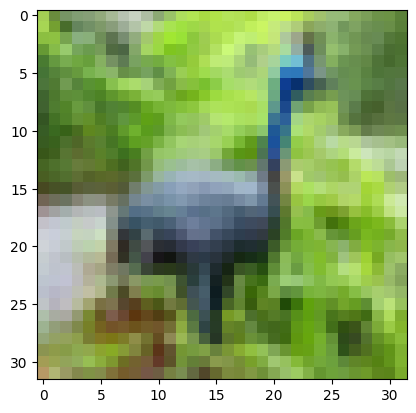

bird


In [ ]:
index = 6
plt.imshow(X_train[index],cmap='gray')
plt.show()
print(class_name[y_train[index][0]])

In [10]:
X_train.shape

(50000, 32, 32, 3)

In [11]:
y_train.shape

(50000, 1)

In [12]:
X_test.shape

(10000, 32, 32, 3)

In [13]:
y_test.shape

(10000, 1)

In [14]:
X_test.max()

255

In [15]:
X_train = X_train / 255
X_test = X_test / 255

In [16]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [17]:
reg = keras.regularizers.l2(0.0003)

In [18]:
# model architecture >>> Sequential
model = keras.models.Sequential()
model.add(Input(shape=(32,32,3)))
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=1,padding='same',activation='relu',
                 kernel_regularizer=reg,name='conv1'))
model.add(Dropout(0.25,name = 'drop1'))
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv2'))
model.add(Dropout(0.25,name = 'drop2'))
model.add(MaxPool2D(name='pool1'))
model.add(Conv2D(filters=64,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv3'))
model.add(Dropout(0.25,name = 'drop3'))
model.add(Conv2D(filters=64,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv4'))
model.add(Dropout(0.25,name = 'drop4'))
model.add(MaxPool2D(name='pool2'))
model.add(Conv2D(filters=128,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv5'))
model.add(Dropout(0.25,name = 'drop5'))
model.add(Conv2D(filters=128,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv6'))
model.add(Dropout(0.25,name = 'drop6'))
model.add(Flatten(name='flatten'))
model.add(Dense(units=512,activation='relu',name = 'hidden1',kernel_regularizer=reg))
model.add(Dropout(0.5,name = 'drop7'))
model.add(Dense(units=10,activation='softmax',kernel_regularizer=reg ,name = 'output'))

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop1 (Dropout)                      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop2 (Dropout)                      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop3 (Dropout)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv4 (Conv2D)                       │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop4 (Dropout)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv5 (Conv2D)                       │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop5 (Dropout)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv6 (Conv2D)                       │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop6 (Dropout)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden1 (Dense)                      │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop7 (Dropout)                      │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,486,954 (17.12 MB)

 Trainable params: 4,486,954 (17.12 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#compile model
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.CategoricalCrossentropy()
metric = tf.metrics.CategoricalAccuracy()
model.compile(optimizer=opt,loss=loss,metrics=[metric])

In [21]:
model.fit(X_train,y_train,epochs=10,batch_size=100,validation_split=0.2,verbose=2)

Epoch 1/10
400/400 - 51s - 127ms/step - categorical_accuracy: 0.3381 - loss: 1.9403 - val_categorical_accuracy: 0.4494 - val_loss: 1.6955
Epoch 2/10
400/400 - 52s - 129ms/step - categorical_accuracy: 0.4856 - loss: 1.5425 - val_categorical_accuracy: 0.5380 - val_loss: 1.4733
Epoch 3/10
400/400 - 54s - 136ms/step - categorical_accuracy: 0.5566 - loss: 1.3882 - val_categorical_accuracy: 0.5694 - val_loss: 1.3659
Epoch 4/10
400/400 - 58s - 144ms/step - categorical_accuracy: 0.6041 - loss: 1.2884 - val_categorical_accuracy: 0.6093 - val_loss: 1.2827
Epoch 5/10
400/400 - 57s - 142ms/step - categorical_accuracy: 0.6402 - loss: 1.2127 - val_categorical_accuracy: 0.6549 - val_loss: 1.2067
Epoch 6/10
400/400 - 55s - 137ms/step - categorical_accuracy: 0.6628 - loss: 1.1646 - val_categorical_accuracy: 0.6845 - val_loss: 1.1243
Epoch 7/10
400/400 - 55s - 139ms/step - categorical_accuracy: 0.6862 - loss: 1.1135 - val_categorical_accuracy: 0.7152 - val_loss: 1.0476
Epoch 8/10
400/400 - 56s - 141ms/s

In [22]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - categorical_accuracy: 0.7491 - loss: 0.9965


[1.002036690711975, 0.746999979019165]

In [23]:
# keras functional api

In [24]:
reg = keras.regularizers.l2(0.0003)

In [31]:
# model architecture >>> Functional api
from keras.models import Model

# Define input layer
inputs = Input(shape=(32, 32, 3), name='input_layer')

# Block 1
block1 = Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv1')(inputs)
block1 = Dropout(0.25, name='drop1')(block1)
block1 = Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv2')(block1)
block1 = Dropout(0.25, name='drop2')(block1)
block1 = MaxPool2D(name='pool1')(block1)

# Block 2
block2 = Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv3')(block1)
block2 = Dropout(0.25, name='drop3')(block2)
block2 = Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv4')(block2)
block2 = Dropout(0.25, name='drop4')(block2)
block2 = MaxPool2D(name='pool2')(block2)

# Block 3
block3 = Conv2D(filters=128, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv5')(block2)
block3 = Dropout(0.25, name='drop5')(block3)
block3 = Conv2D(filters=128, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv6')(block3)
block3 = Dropout(0.25, name='drop6')(block3)

# Classification layer
flattened = Flatten(name='flatten')(block3)
hidden_layer = Dense(units=512, activation='relu', kernel_regularizer=reg, name='hidden1')(flattened)
hidden_layer = Dropout(0.5, name='drop7')(hidden_layer)
outputs = Dense(units=10, activation='softmax', kernel_regularizer=reg, name='output')(hidden_layer)

# Define model
model_functional = Model(inputs=inputs, outputs=outputs)

In [32]:
model_functional.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop1 (Dropout)                      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop2 (Dropout)                      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop3 (Dropout)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv4 (Conv2D)                       │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop4 (Dropout)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv5 (Conv2D)                       │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop5 (Dropout)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv6 (Conv2D)                       │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop6 (Dropout)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden1 (Dense)                      │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop7 (Dropout)                      │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,486,954 (17.12 MB)

 Trainable params: 4,486,954 (17.12 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
#compile model
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.CategoricalCrossentropy()
metric = tf.metrics.CategoricalAccuracy()
model_functional.compile(optimizer=opt,loss=loss,metrics=[metric])

In [34]:
model_functional.fit(X_train,y_train,epochs=10,batch_size=100,validation_split=0.2,verbose=2)

Epoch 1/10
400/400 - 54s - 134ms/step - categorical_accuracy: 0.3487 - loss: 1.8900 - val_categorical_accuracy: 0.4544 - val_loss: 1.6537
Epoch 2/10
400/400 - 57s - 141ms/step - categorical_accuracy: 0.4958 - loss: 1.5170 - val_categorical_accuracy: 0.5556 - val_loss: 1.4199
Epoch 3/10
400/400 - 57s - 142ms/step - categorical_accuracy: 0.5679 - loss: 1.3707 - val_categorical_accuracy: 0.6099 - val_loss: 1.2793
Epoch 4/10
400/400 - 58s - 144ms/step - categorical_accuracy: 0.6123 - loss: 1.2682 - val_categorical_accuracy: 0.6534 - val_loss: 1.1848
Epoch 5/10
400/400 - 58s - 144ms/step - categorical_accuracy: 0.6450 - loss: 1.2036 - val_categorical_accuracy: 0.6626 - val_loss: 1.1718
Epoch 6/10
400/400 - 60s - 151ms/step - categorical_accuracy: 0.6671 - loss: 1.1565 - val_categorical_accuracy: 0.6979 - val_loss: 1.0981
Epoch 7/10
400/400 - 59s - 147ms/step - categorical_accuracy: 0.6870 - loss: 1.1211 - val_categorical_accuracy: 0.7061 - val_loss: 1.0893
Epoch 8/10
400/400 - 59s - 147ms/s

In [35]:
model_functional.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - categorical_accuracy: 0.7294 - loss: 1.0692


[1.0750421285629272, 0.7276999950408936]